In [4]:
import zipfile
path = zipfile.ZipFile('/content/mask.zip')
path.extractall("Mask_and_no-mask")

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
!pip install split-folders
import splitfolders

In [7]:
splitfolders.ratio("/content/Mask_and_no-mask",ratio=(0.7,0.2,0.1),output='today_mask_and_nomask')

Copying files: 0 files [00:00, ? files/s]


In [8]:
# 0.7 is training 0.2 is validating and 0.1 is testing

In [13]:
import os

# The splitfolders command in the previous cell likely failed to copy files.
# Let's check the structure and load the training set correctly.
training = tf.keras.utils.image_dataset_from_directory(
    '/content/today_mask_and_nomask/train',
    image_size = (128, 128),
    batch_size = 32,
    shuffle = True,
    seed = 42
)

print(f"Classes: {training.class_names}")

Found 5286 files belonging to 2 classes.
Classes: ['with_mask', 'without_mask']


In [14]:
# Load Validation set
validation = tf.keras.utils.image_dataset_from_directory(
    '/content/today_mask_and_nomask/val',
    image_size = (128, 128),
    batch_size = 32,
    shuffle = True,
    seed = 42
)

# Load Testing set
testing = tf.keras.utils.image_dataset_from_directory(
    '/content/today_mask_and_nomask/test',
    image_size = (128, 128),
    batch_size = 32,
    shuffle = False
)

print(f"Validation Classes: {validation.class_names}")
print(f"Testing Classes: {testing.class_names}")

Found 1510 files belonging to 2 classes.
Found 757 files belonging to 2 classes.
Validation Classes: ['with_mask', 'without_mask']
Testing Classes: ['with_mask', 'without_mask']


In [19]:
from PIL import Image
import cv2
from IPython.display import Image


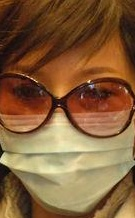

In [20]:
Image("/content/today_mask_and_nomask/train/with_mask/with_mask_10.jpg")

array([[[207, 194, 202],
        [203, 190, 198],
        [197, 186, 194],
        ...,
        [195, 189, 194],
        [197, 194, 196],
        [199, 196, 198]],

       [[207, 194, 202],
        [207, 194, 202],
        [205, 192, 200],
        ...,
        [192, 186, 191],
        [199, 196, 198],
        [203, 200, 202]],

       [[206, 191, 199],
        [205, 192, 200],
        [203, 190, 198],
        ...,
        [171, 166, 168],
        [191, 188, 190],
        [199, 196, 198]],

       ...,

       [[119,  91,  97],
        [158, 130, 136],
        [196, 170, 176],
        ...,
        [172, 148, 158],
        [198, 174, 184],
        [213, 192, 201]],

       [[132, 104, 110],
        [172, 144, 150],
        [203, 177, 183],
        ...,
        [127, 102, 112],
        [159, 134, 144],
        [184, 160, 170]],

       [[154, 129, 133],
        [192, 167, 171],
        [218, 193, 197],
        ...,
        [ 79,  52,  61],
        [111,  84,  93],
        [137, 113, 121]]], dtype=uint8)
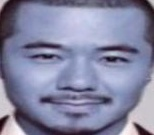

In [24]:
cv2.imread("/content/today_mask_and_nomask/train/without_mask/without_mask_10.jpg")

In [27]:
model = keras.Sequential([
    layers.Conv2D(32,(3,3),padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),padding='same'),
    layers.MaxPooling2D(2,2),
    #Feature extraction

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')

    ])

In [32]:
model.compile(optimizer='Adadelta',loss='binary_crossentropy',metrics=['accuracy'])

In [33]:
model.fit(training,epochs=10,validation_data=testing)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9714 - loss: 0.0804 - val_accuracy: 0.9022 - val_loss: 0.4249
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9760 - loss: 0.0683 - val_accuracy: 0.9009 - val_loss: 0.4149
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9782 - loss: 0.0646 - val_accuracy: 0.8996 - val_loss: 0.4096
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9788 - loss: 0.0623 - val_accuracy: 0.8996 - val_loss: 0.4066
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9801 - loss: 0.0605 - val_accuracy: 0.9022 - val_loss: 0.4020
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9803 - loss: 0.0592 - val_accuracy: 0.9022 - val_loss: 0.4019
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9813 - loss: 0.0582 - val_accuracy: 0.9049 - val_loss: 0.4009
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9818 - loss: 0.0572 - val_ac

In [35]:
import numpy as np
import gradio as gr

def predict_mask(img):
    img = img.resize((128, 128))
    img = np.expand_dims(np.array(img), axis=0)

    prediction = model.predict(img)[0][0]

    if prediction < 0.5:
        return f"With Mask ({1-prediction:.2f})"
    return f"Without Mask ({prediction:.2f})"

gr.Interface(
    predict_mask,
    gr.Image(type="pil"),
    "text",
    title="Face Mask Detection"
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a61cb3be0f06d68fe.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
